In [1]:
import numpy as np
import struct
from array import array
from os.path  import join

%matplotlib inline
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
# MNist reader from:
# https://www.kaggle.com/code/hojjatk/read-mnist-dataset

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append(np.zeros((rows, cols)))
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)   

In [3]:
input_path = 'mnist'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

In [4]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1
        plt.show

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_to_show = []
titles_to_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_to_show.append(x_train[r])
    titles_to_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_to_show.append(x_test[r])        
    titles_to_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

#show_images(images_to_show, titles_to_show)

#plt.show()

# end of code from
# https://www.kaggle.com/code/hojjatk/read-mnist-dataset

In [5]:
class MNistDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return torch.tensor(self.x[i], dtype=torch.float32), self.y[i]

dataset = MNistDataset(x_train, y_train)
test_dataset = MNistDataset(x_test, y_test)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True,
)

In [6]:
count = 0
for x in test_loader:
    count += 1
    if count > 1000:
        break
print(count)

313


In [7]:
class ConvModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn1 = nn.BatchNorm2d(20)
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn2 = nn.BatchNorm2d(20)
        self.conv3 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn3 = nn.BatchNorm2d(20)

        self.drop1 = nn.Dropout(0.1)

        self.conv4 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn4 = nn.BatchNorm2d(20)
        self.conv5 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn5 = nn.BatchNorm2d(20)

        self.drop2 = nn.Dropout(0.1)

        self.conv6 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn6 = nn.BatchNorm2d(20)
        self.conv7 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn7 = nn.BatchNorm2d(20)
        self.conv8 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=(3, 3), padding="same")
        self.bn8 = nn.BatchNorm2d(20)
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.lin1 = nn.Linear(20, 20)
        self.lin2 = nn.Linear(20, 10)

    def forward(self, x):
        # normalize
        x = (x / 128) - 0.5
        x.unsqueeze_(-3)
        # (1, 28, 28)
        x = self.conv1(x)
        # (20, 28, 28)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn1(x)

        x = self.conv2(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn2(x)

        x = self.conv3(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn3(x)

        x = self.drop1(x)

        x = self.conv4(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn4(x)
        
        x = self.conv5(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn5(x)

        x = self.drop2(x)
        
        x = self.conv6(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn6(x)

        
        x = self.conv7(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn7(x)

        x = self.conv8(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.bn8(x)

        x = self.pool(x)
        x = x.reshape((-1, 20, ))
        x = self.lin1(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = self.lin2(x)

        return x
        


In [8]:
model = ConvModel()
model_hooks = []

In [9]:
# how many params
sum([p.numel() for p in model.parameters()])

26490

In [10]:
# check that model runs and shapes work
model(torch.tensor(x_train[2], dtype=torch.float32).unsqueeze(0))

tensor([[ 0.1981,  0.0432,  0.2365, -0.1358,  0.1689,  0.0161,  0.0256,  0.0918,
          0.3390,  0.0411]], grad_fn=<AddmmBackward0>)

In [11]:
# training loop

n_batches = 5000
cross_entropy = nn.CrossEntropyLoss()
lr = 0.01

# not doing weight decay for now
# l2_lambda = 0
# decay = []
# for p in model.parameters():
#     if p.requires_grad and p.dim() > 1:
#         decay.append(p)

def test_loss():
    model.eval()
    cml_loss = 0
    cml_items = 0
    for x, y in test_loader:
        n_items = x.shape[0]
        with torch.no_grad():
            y_pred = model(x)
        loss = cross_entropy(y_pred, y)
        cml_loss += loss.item() * n_items
        cml_items += n_items
    model.train()
    print(f"Computed test loss over {cml_items} items")
    return cml_loss / cml_items

for i in range(n_batches):
    x, y = loader.__iter__().__next__()
    y_pred = model(x)
    loss = cross_entropy(y_pred, y)
    if i % 250 == 0 or i == n_batches - 1:
        print(f"Loss at step {i:4} is {loss.item():0.3f}")
        print(f"Test loss at step {i:4} is {test_loss():0.3f}")

    # for p in decay:
    #     loss += l2_lambda * (p*p).mean()

    loss.backward()

    for p in model.parameters():
        p.data -= lr * p.grad
    model.zero_grad()

Loss at step    0 is 2.293
Computed test loss over 10000 items
Test loss at step    0 is 2.310
Loss at step  250 is 2.158
Computed test loss over 10000 items
Test loss at step  250 is 2.142
Loss at step  500 is 2.133
Computed test loss over 10000 items
Test loss at step  500 is 1.993
Loss at step  750 is 1.850
Computed test loss over 10000 items
Test loss at step  750 is 1.802
Loss at step 1000 is 1.742
Computed test loss over 10000 items
Test loss at step 1000 is 1.675
Loss at step 1250 is 1.649
Computed test loss over 10000 items
Test loss at step 1250 is 1.548
Loss at step 1500 is 1.280
Computed test loss over 10000 items
Test loss at step 1500 is 1.359
Loss at step 1750 is 1.007
Computed test loss over 10000 items
Test loss at step 1750 is 1.132
Loss at step 2000 is 0.920
Computed test loss over 10000 items
Test loss at step 2000 is 0.899
Loss at step 2250 is 0.781
Computed test loss over 10000 items
Test loss at step 2250 is 0.726
Loss at step 2500 is 1.011
Computed test loss over

In [14]:
cml_loss = 0
count = 0
for idx in range(200, 215):
    x, y = test_dataset[idx]
    #show_images([x], [y])
    #plt.show()
    model.eval()
    res = model(torch.tensor(x, dtype=torch.float32).unsqueeze(0))
    model.train()
    #print(res)
    loss = cross_entropy(res, torch.tensor([y])).item()
    print(f"{idx:5} -- {loss:0.2f}")
    cml_loss += loss
    count += 1

print(f"Average: {cml_loss/count:0.2f}")




  200 -- 0.07
  201 -- 0.03
  202 -- 0.00
  203 -- 0.00
  204 -- 0.01
  205 -- 0.33
  206 -- 0.04
  207 -- 0.16
  208 -- 0.02
  209 -- 0.19
  210 -- 0.00
  211 -- 0.59
  212 -- 0.05
  213 -- 0.05
  214 -- 0.07
Average: 0.11


/var/folders/ms/0vlwf73n4b94x2rzprg21g700000gn/T/ipykernel_30621/339713388.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res = model(torch.tensor(x, dtype=torch.float32).unsqueeze(0))


In [29]:
def test_accuracy():
    model.eval()
    cml_correct = 0
    cml_items = 0
    for x, y in test_loader:
        n_items = x.shape[0]
        with torch.no_grad():
            y_pred = model(x)
        predictions = torch.argmax(y_pred, dim=1)
        cml_correct += (y == predictions).sum().item()
        cml_items += n_items
    model.train()
    print(f"Computed test accuracy over {cml_items} items")
    return cml_correct / cml_items

test_accuracy()

Computed test accuracy over 10000 items


0.9572

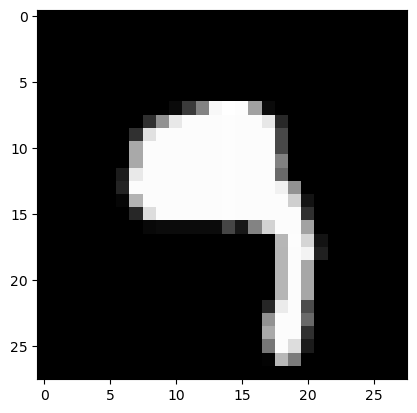

9
tensor([[-4.2399, -0.0655,  2.3171, -3.4312,  4.6771, -7.2273, -3.1243,  7.7849,
         -2.7398,  7.8009]], grad_fn=<AddmmBackward0>)
tensor(0.7094, grad_fn=<NllLossBackward0>)


/var/folders/ms/0vlwf73n4b94x2rzprg21g700000gn/T/ipykernel_29392/2944026555.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = model(torch.tensor(x, dtype=torch.float32).unsqueeze(0))


In [12]:
x, y = test_dataset[209]
fig, ax = plt.subplots()
ax.imshow(x, cmap=plt.cm.gray)
plt.show()
print(y)
model.eval()
y_pred = model(torch.tensor(x, dtype=torch.float32).unsqueeze(0))
print(y_pred)
print(cross_entropy(y_pred, torch.tensor([y])))

In [13]:
def print_stats(t, name = ""):
    print(f"Tensor stats: {name}")
    print(f"  Mean: {t.mean():.2e}")
    print(f"  Second moment: {(t * t).mean():.2e}")
    print(f"  Standard dev: {t.std():.2e}")
    print(f"  Min: {torch.min(t):.2e}")
    print(f"      10th quantile: {torch.quantile(t, 0.1):.2e}")
    print(f"      90th quantile: {torch.quantile(t, 0.9):.2e}")
    print(f"  Max: {torch.max(t):.2e}")

def print_param_stats(model):
    for n, p in model.named_parameters():
        if p.dim() > 1:
            print_stats(p, name=n)

In [14]:

print_param_stats(model)

Tensor stats: conv1.weight
  Mean: -2.70e-03
  Second moment: 3.88e-02
  Standard dev: 1.97e-01
  Min: -3.43e-01
      10th quantile: -2.77e-01
      90th quantile: 2.62e-01
  Max: 3.74e-01
Tensor stats: conv2.weight
  Mean: -3.44e-03
  Second moment: 2.41e-03
  Standard dev: 4.90e-02
  Min: -1.87e-01
      10th quantile: -6.86e-02
      90th quantile: 6.17e-02
  Max: 1.42e-01
Tensor stats: conv3.weight
  Mean: -3.39e-04
  Second moment: 2.15e-03
  Standard dev: 4.63e-02
  Min: -1.34e-01
      10th quantile: -6.12e-02
      90th quantile: 6.11e-02
  Max: 1.36e-01
Tensor stats: conv4.weight
  Mean: 1.42e-03
  Second moment: 1.98e-03
  Standard dev: 4.45e-02
  Min: -1.11e-01
      10th quantile: -5.77e-02
      90th quantile: 5.96e-02
  Max: 1.33e-01
Tensor stats: conv5.weight
  Mean: -2.47e-03
  Second moment: 1.97e-03
  Standard dev: 4.44e-02
  Min: -1.33e-01
      10th quantile: -6.08e-02
      90th quantile: 5.65e-02
  Max: 1.37e-01
Tensor stats: conv6.weight
  Mean: -2.62e-04
  Seco

In [15]:
model.conv4.weight.shape

torch.Size([20, 20, 3, 3])

In [16]:
for handle in model_hooks:
    handle.remove()

def print_vals_one_sample(module, x, y):
    y = y.detach()
    print(f"Output of {module}")
    print(f"Mean: {y.mean()}")
    print(f"First few values: {y.flatten()[0:5]}")

layer_stds = []

def print_layer_std(module, x, y):
    y = y.detach()
    fig, ax = plt.subplots()
    ax.imshow(y.std(dim=0)[0], cmap=plt.cm.gray)
    plt.show()
    layer_stds.append(y.std(dim=0)[0])

def print_grad_stats(grad):
    print(f"Gradient stats:")
    print(f"  Mean: {grad.mean():.2e}")
    print(f"  Second moment: {(grad * grad).mean():.2e}")
    print(f"  10th quantile: {torch.quantile(grad, 0.1):.2e}")
    print(f"  90th quantile: {torch.quantile(grad, 0.9):.2e}")

model_hooks.append(model.conv4.weight.register_hook(print_grad_stats))

In [17]:
layer_stds[0]

IndexError: list index out of range